<a href="https://colab.research.google.com/github/PrashantMahajan24/Business-Health-Dashboard/blob/main/DeepLearningProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import os

# Check if the captions file exists
if os.path.exists('/content/captions.txt'):
    print("✅ captions.txt successfully uploaded.")

# Set image_folder directly to the correct path
image_folder = '/content/image_captioning/Image'

# Now count the images from the determined image_folder
if os.path.exists(image_folder) and os.path.isdir(image_folder):
    num_images = len(os.listdir(image_folder))
    print(f"📸 Total images found in '{image_folder}': {num_images}")
else:
    print(f"❌ Image directory '{image_folder}' does not exist or is not a directory.")
    num_images = 0 # Set to 0 to avoid errors if directory is still not found

# Make image_path globally accessible
global image_path
image_path = image_folder

✅ captions.txt successfully uploaded.
❌ Image directory '/content/image_captioning/Image' does not exist or is not a directory.


In [43]:
import pandas as pd

# image_path is now set globally by kzPkS_yEHsnO
# Ensure it's explicitly set here as well for clarity or if kzPkS_yEHsnO isn't run first
image_path = "/content/image_captioning/Image"
data = pd.read_csv("/content/captions.txt")
data.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [38]:
## 📦 Imports and Setup

import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import Sequence
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Activation, Dropout, Flatten, Dense, Input, Layer
from tensorflow.keras.layers import Embedding, LSTM, add, Concatenate, Reshape, concatenate, Bidirectional
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet201
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from textwrap import wrap

plt.rcParams['font.size'] = 12
sns.set_style("dark")
warnings.filterwarnings('ignore')

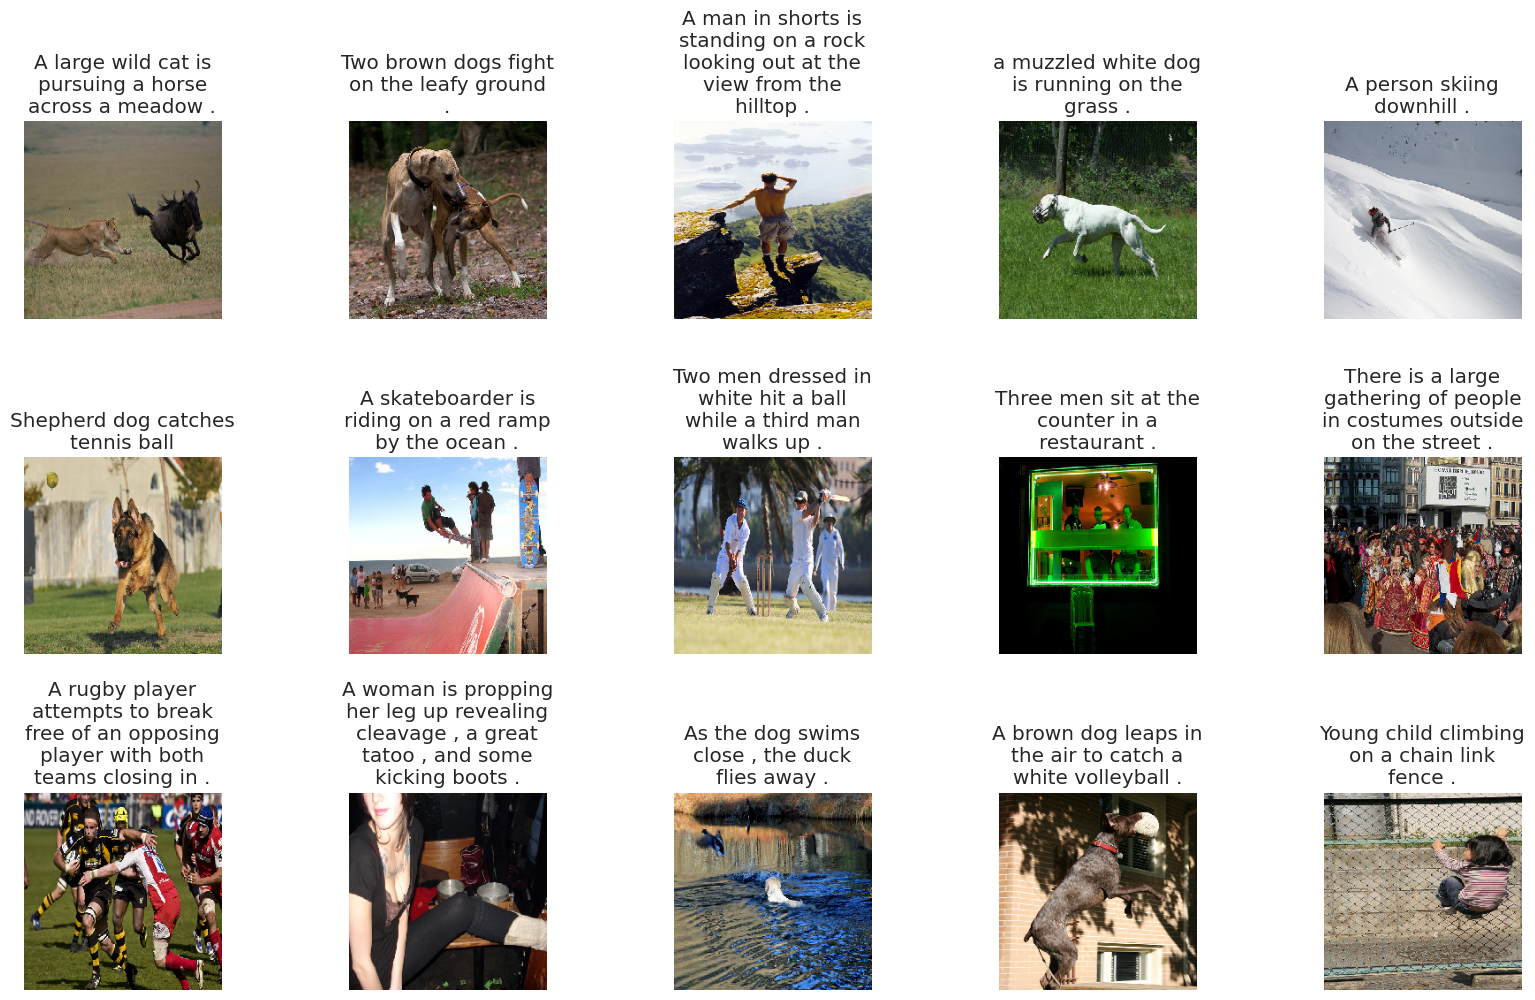

In [47]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array
from textwrap import wrap

# Actual image folder
image_folder = "/content/dataset/Images"


# Helper: Load image and resize
def readImage(path, img_size=224):
    img = load_img(
        path,
        color_mode='rgb',
        target_size=(img_size, img_size)
    )
    img = img_to_array(img) / 255.0
    return img


# Helper: Show random images with captions
def display_images(temp_df):

    temp_df = temp_df.reset_index(drop=True)

    # Check which images actually exist
    available_images = set(os.listdir(image_folder))

    temp_df = temp_df[
        temp_df['image'].str.strip().isin(available_images)
    ].reset_index(drop=True)

    # Select maximum 15 images
    n = min(15, len(temp_df))

    if n == 0:
        print("❌ No matching images found.")
        return

    sample_df = temp_df.sample(
        n=n,
        random_state=42
    ).reset_index(drop=True)

    plt.figure(figsize=(20, 20))

    for i in range(n):

        plt.subplot(5, 5, i + 1)

        image_name = sample_df.loc[i, 'image'].strip()

        image_path = os.path.join(
            image_folder,
            image_name
        )

        image = readImage(image_path)

        plt.imshow(image)

        plt.title(
            "\n".join(
                wrap(
                    str(sample_df.loc[i, 'caption']),
                    20
                )
            )
        )

        plt.axis("off")

    plt.subplots_adjust(
        hspace=0.7,
        wspace=0.3
    )

    plt.show()


display_images(data)

In [45]:
import os

image_extensions = ('.jpg', '.jpeg', '.png', '.webp')

for root, dirs, files in os.walk('/content'):
    count = sum(
        1 for f in files
        if f.lower().endswith(image_extensions)
    )

    if count > 100:
        print(f"📁 {root} → {count} images")

📁 /content/dataset/Images → 8091 images


In [ ]:
import os
print(os.listdir('/content/image_captioning'))

['.ipynb_checkpoints', 'captions.txt', 'Image']


In [46]:
image_folder = "/content/dataset/Images"

In [48]:
def text_preprocessing(data):
    data['caption'] = data['caption'].apply(lambda x: x.lower())
    data['caption'] = data['caption'].str.replace("[^a-z ]", "", regex=True)
    data['caption'] = data['caption'].str.replace("\s+", " ", regex=True)
    data['caption'] = data['caption'].apply(lambda x: " ".join([word for word in x.split() if len(word) > 1]))
    data['caption'] = "startseq " + data['caption'] + " endseq"
    return data

data = text_preprocessing(data)
captions = data['caption'].tolist()
captions[:10]

['startseq child in pink dress is climbing up set of stairs in an entry way endseq',
 'startseq girl going into wooden building endseq',
 'startseq little girl climbing into wooden playhouse endseq',
 'startseq little girl climbing the stairs to her playhouse endseq',
 'startseq little girl in pink dress going into wooden cabin endseq',
 'startseq black dog and spotted dog are fighting endseq',
 'startseq black dog and tricolored dog playing with each other on the road endseq',
 'startseq black dog and white dog with brown spots are staring at each other in the street endseq',
 'startseq two dogs of different breeds looking at each other on the road endseq',
 'startseq two dogs on pavement moving toward each other endseq']

In [49]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(captions)
vocabe_size = len(tokenizer.word_index) + 1
max_length = max(len(caption.split()) for caption in captions)

# Strip whitespaces from the image column globally
data['image'] = data['image'].str.strip()

images = data['image'].unique().tolist()
nimages = len(images)

split_index = round(0.85 * nimages)
train_images = images[:split_index]
val_images = images[split_index:]

train = data[data['image'].isin(train_images)]
test = data[data['image'].isin(val_images)]

train.reset_index(inplace=True, drop=True)
test.reset_index(inplace=True, drop=True)

tokenizer.texts_to_sequences([captions[1]])[0]

[1, 18, 312, 63, 192, 116, 2]

In [50]:
caption = train.iloc[0]['caption']

print("Caption:", caption)

seq = tokenizer.texts_to_sequences([caption])[0]

print("Sequence:", seq)
print("Sequence length:", len(seq))

Caption: startseq child in pink dress is climbing up set of stairs in an entry way endseq
Sequence: [1, 41, 3, 89, 168, 6, 118, 52, 393, 11, 390, 3, 27, 5192, 691, 2]
Sequence length: 16


In [52]:
import os

image_extensions = ('.jpg', '.jpeg', '.png', '.webp')

for root, dirs, files in os.walk('/content'):
    count = sum(
        1 for f in files
        if f.lower().endswith(image_extensions)
    )

    if count > 100:
        print(f"📁 {root} → {count} images")

📁 /content/dataset/Images → 8091 images


In [56]:
import numpy as np
from tqdm import tqdm
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.models import Model
from tensorflow.keras.utils import load_img, img_to_array

# Load DenseNet201
model = DenseNet201()

# Remove classification layer
fe = Model(
    inputs=model.input,
    outputs=model.layers[-2].output
)

img_size = 224

features = {}

for image in tqdm(data['image'].unique().tolist()):

    # Remove extra spaces
    image = image.strip()

    # Create correct image path
    img_path = os.path.join(image_path, image)

    # Check image exists
    if not os.path.exists(img_path):
        print(f"\n⚠️ Image not found: {img_path}")
        continue

    # Load image
    img = load_img(
        img_path,
        target_size=(img_size, img_size)
    )

    # Convert image to array
    img = img_to_array(img)

    # Normalize
    img = img / 255.0

    # Add batch dimension
    img = np.expand_dims(img, axis=0)

    # Extract features
    feature = fe.predict(img, verbose=0)

    features[image] = feature

print(f"\n✅ Features extracted for {len(features)} images")

100%|██████████| 8091/8091 [15:26<00:00,  8.73it/s]


✅ Features extracted for 8091 images


In [57]:
from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np


class CustomDataGenerator(Sequence):

    def __init__(
        self,
        df,
        X_col,
        y_col,
        batch_size,
        directory,
        tokenizer,
        vocab_size,
        max_length,
        features,
        shuffle=True
    ):

        self.df = df.copy()

        # Clean image names
        self.df[X_col] = self.df[X_col].str.strip()

        self.X_col = X_col
        self.y_col = y_col
        self.directory = directory
        self.batch_size = batch_size
        self.tokenizer = tokenizer
        self.vocab_size = vocab_size
        self.max_length = max_length
        self.features = features
        self.shuffle = shuffle

        self.n = len(self.df)

        self.on_epoch_end()


    def on_epoch_end(self):

        if self.shuffle:
            self.df = self.df.sample(
                frac=1,
                random_state=None
            ).reset_index(drop=True)


    def __len__(self):

        # Include the last incomplete batch
        return int(np.ceil(self.n / self.batch_size))


    def __getitem__(self, index):

        start = index * self.batch_size
        end = min((index + 1) * self.batch_size, self.n)

        batch = self.df.iloc[start:end]

        X1, X2, y = self.__get_data(batch)

        return (np.array(X1), np.array(X2)), np.array(y)


    def __get_data(self, batch):

        X1 = []
        X2 = []
        y = []

        images = batch[self.X_col].tolist()

        for image in images:

            image = image.strip()

            # Check whether feature exists
            if image not in self.features:
                continue

            # Image feature from DenseNet
            feature = self.features[image][0]

            # Get captions for this image
            captions = batch.loc[
                batch[self.X_col] == image,
                self.y_col
            ].tolist()

            for caption in captions:

                # Convert caption to integer sequence
                seq = self.tokenizer.texts_to_sequences(
                    [caption]
                )[0]

                # Create training sequences
                for i in range(1, len(seq)):

                    # Input sequence
                    in_seq = seq[:i]

                    # Output word
                    out_seq = seq[i]

                    # Padding input sequence
                    in_seq = pad_sequences(
                        [in_seq],
                        maxlen=self.max_length
                    )[0]

                    # One-hot encode output word
                    out_seq = to_categorical(
                        [out_seq],
                        num_classes=self.vocab_size
                    )[0]

                    X1.append(feature)
                    X2.append(in_seq)
                    y.append(out_seq)

        return X1, X2, y

In [53]:
image_path = "/content/dataset/Images"

In [58]:
input1 = Input(shape=(1920,))
input2 = Input(shape=(max_length,))

img_features = Dense(256, activation='relu')(input1)
img_features_reshaped = Reshape((1, 256))(img_features)

sentence_features = Embedding(vocabe_size, 256, mask_zero=False)(input2)
merged = concatenate([img_features_reshaped, sentence_features], axis=1)
sentence_features = LSTM(256)(merged)

x = Dropout(0.5)(sentence_features)
x = add([x, img_features])
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(vocabe_size, activation='softmax')(x)

caption_model = Model(inputs=[input1, input2], outputs=output)
caption_model.compile(loss='categorical_crossentropy', optimizer='adam')

In [54]:
import os
from tensorflow.keras.utils import load_img

test_image = data['image'].iloc[0].strip()

test_path = os.path.join(image_path, test_image)

print("Image:", test_image)
print("Path:", test_path)
print("Exists:", os.path.exists(test_path))

Image: 1000268201_693b08cb0e.jpg
Path: /content/dataset/Images/1000268201_693b08cb0e.jpg
Exists: True


In [55]:
img = load_img(test_path, target_size=(224, 224))

print("✅ Image loaded successfully!")

✅ Image loaded successfully!


In [59]:
train_generator = CustomDataGenerator(train, 'image', 'caption', 64, image_path, tokenizer, vocabe_size, max_length, features)
validation_generator = CustomDataGenerator(test, 'image', 'caption', 64, image_path, tokenizer, vocabe_size, max_length, features)

callbacks = [
    ModelCheckpoint("model.h5", monitor="val_loss", save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.2, min_lr=1e-8)
]

history = caption_model.fit(train_generator, validation_data=validation_generator, epochs=20, callbacks=callbacks)

Epoch 1/20
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 5.7332
Epoch 1: val_loss improved from None to 4.32510, saving model to model.h5



Epoch 1: finished saving model to model.h5
538/538 ━━━━━━━━━━━━━━━━━━━━ 98s 175ms/step - loss: 5.1257 - val_loss: 4.3251 - learning_rate: 0.0010
Epoch 2/20
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 4.3760
Epoch 2: val_loss improved from 4.32510 to 4.00523, saving model to model.h5



Epoch 2: finished saving model to model.h5
538/538 ━━━━━━━━━━━━━━━━━━━━ 90s 168ms/step - loss: 4.3082 - val_loss: 4.0052 - learning_rate: 0.0010
Epoch 3/20
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 4.0725
Epoch 3: val_loss improved from 4.00523 to 3.85801, saving model to model.h5



Epoch 3: finished saving model to model.h5
538/538 ━━━━━━━━━━━━━━━━━━━━ 90s 167ms/step - loss: 4.0449 - val_loss: 3.8580 - learning_rate: 0.0010
Epoch 4/20
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 3.8837
Epoch 4: val_loss improved from 3.85801 to 3.77370, saving model to model.h5



Epoch 4: finished saving model to model.h5
538/538 ━━━━━━━━━━━━━━━━━━━━ 89s 166ms/step - loss: 3.8756 - val_loss: 3.7737 - learning_rate: 0.0010
Epoch 5/20
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 3.7500
Epoch 5: val_loss improved from 3.77370 to 3.71187, saving model to model.h5


...


Epoch 6: finished saving model to model.h5
538/538 ━━━━━━━━━━━━━━━━━━━━ 86s 159ms/step - loss: 3.6572 - val_loss: 3.6857 - learning_rate: 0.0010
Epoch 7/20
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 3.5665
Epoch 7: val_loss improved from 3.68565 to 3.67396, saving model to model.h5



Epoch 7: finished saving model to model.h5
538/538 ━━━━━━━━━━━━━━━━━━━━ 90s 167ms/step - loss: 3.5770 - val_loss: 3.6740 - learning_rate: 0.0010
Epoch 8/20
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 3.5058
Epoch 8: val_loss improved from 3.67396 to 3.65984, saving model to model.h5



Epoch 8: finished saving model to model.h5
538/538 ━━━━━━━━━━━━━━━━━━━━ 88s 163ms/step - loss: 3.5111 - val_loss: 3.6598 - learning_rate: 0.0010
Epoch 9/20
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 3.4401
Epoch 9: val_loss improved from 3.65984 to 3.65264, saving model to model.h5



Epoch 9: finished saving model to model.h5
538/538 ━━━━━━━━━━━━━━━━━━━━ 83s 155ms/step - loss: 3.4511 - val_loss: 3.6526 - learning_rate: 0.0010
Epoch 10/20
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 3.3874
Epoch 10: val_loss improved from 3.65264 to 3.64874, saving model to model.h5



Epoch 10: finished saving model to model.h5
538/538 ━━━━━━━━━━━━━━━━━━━━ 87s 162ms/step - loss: 3.3956 - val_loss: 3.6487 - learning_rate: 0.0010
Epoch 11/20
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 3.3345
Epoch 11: val_loss did not improve from 3.64874
538/538 ━━━━━━━━━━━━━━━━━━━━ 88s 163ms/step - loss: 3.3496 - val_loss: 3.6584 - learning_rate: 0.0010
Epoch 12/20
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 3.2896
Epoch 12: val_loss did not improve from 3.64874
538/538 ━━━━━━━━━━━━━━━━━━━━ 87s 162ms/step - loss: 3.3101 - val_loss: 3.6693 - learning_rate: 0.0010
Epoch 13/20
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 3.2525
Epoch 13: val_loss did not improve from 3.64874
538/538 ━━━━━━━━━━━━━━━━━━━━ 84s 156ms/step - loss: 3.2679 - val_loss: 3.6927 - learning_rate: 0.0010
Epoch 14/20
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 3.1823
Epoch 14: val_loss did not improve from 3.64874
538/538 ━━━━━━━━━━━━━━━━━━━━ 83s 154ms/step - loss: 3.1707 - val_loss: 3.71

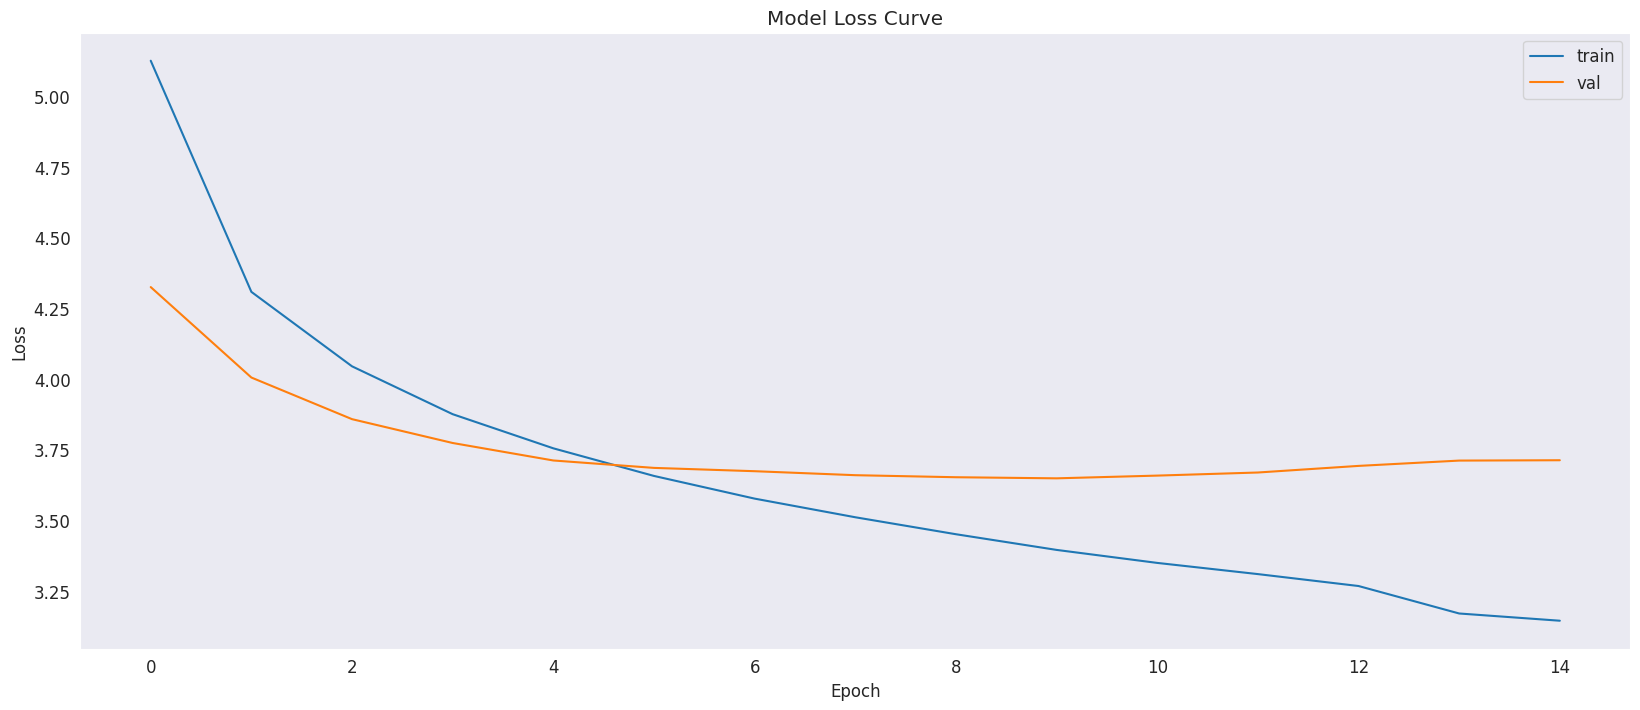

In [60]:
plt.figure(figsize=(20, 8))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Model Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [61]:
def idx_to_word(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

def predict_caption(model, image, tokenizer, max_length, features):
    feature = features[image]
    in_text = "startseq"
    for _ in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        y_pred = model.predict([feature, sequence], verbose=0)
        y_pred = np.argmax(y_pred)
        word = idx_to_word(y_pred, tokenizer)
        if word is None or word == 'endseq':
            break
        in_text += " " + word
    return in_text

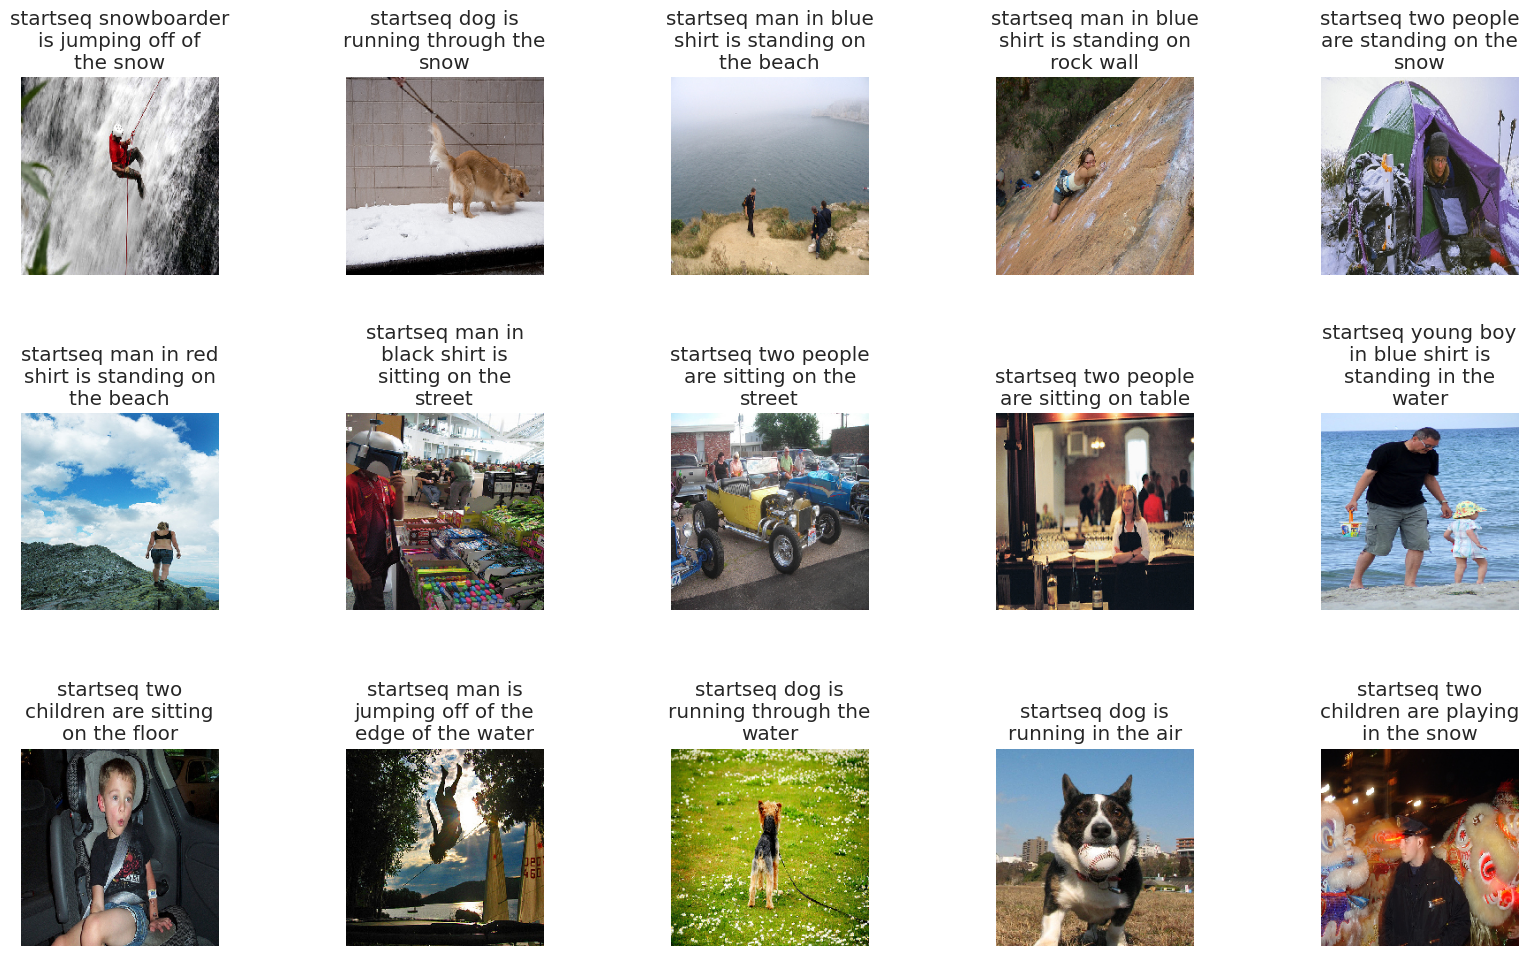

In [62]:
samples = test.sample(15).reset_index(drop=True)
for i, row in samples.iterrows():
    # image_path is now a global variable defined in the new cell
    img = load_img(os.path.join(image_path, row['image']), target_size=(224, 224))
    img = img_to_array(img) / 255.0
    caption = predict_caption(caption_model, row['image'], tokenizer, max_length, features)
    samples.loc[i, 'caption'] = caption

display_images(samples)

In [64]:
import pickle

# Calculate vocab size
vocab_size = len(tokenizer.word_index) + 1

# Calculate max caption length
sequences = tokenizer.texts_to_sequences(data['caption'])
max_length = max(len(seq) for seq in sequences)

print("Vocabulary size:", vocab_size)
print("Max length:", max_length)


# Save captioning model
caption_model.save("caption_model.keras")

# Save tokenizer
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# Save DenseNet feature extractor
fe.save("feature_extractor.keras")

# Save configuration
with open("config.pkl", "wb") as f:
    pickle.dump({
        "max_length": max_length,
        "vocab_size": vocab_size
    }, f)

print("✅ All files saved successfully!")

Vocabulary size: 8768
Max length: 34
✅ All files saved successfully!
